In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("Language Detection.csv")

print("Dataset Shape:", data.shape)
print("\nFirst 5 records:")
print(data.head())


Dataset Shape: (10337, 2)

First 5 records:
                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English


In [4]:
data = data.dropna(subset=["Text", "Language"])

In [5]:
X = data["Text"]
y = data["Language"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [8]:
vectorizer = TfidfVectorizer(analyzer="char",ngram_range=(2, 5),min_df=2)

In [9]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [10]:
model = MultinomialNB()

In [11]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [12]:
y_pred = model.predict(X_test_tfidf)


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


Accuracy: 95.55 %


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       107
      Danish       1.00      0.69      0.81        86
       Dutch       0.98      0.79      0.87       109
     English       0.78      1.00      0.88       277
      French       0.99      0.99      0.99       203
      German       1.00      0.91      0.96        94
       Greek       1.00      1.00      1.00        73
       Hindi       1.00      1.00      1.00        12
     Italian       1.00      0.94      0.97       140
     Kannada       1.00      1.00      1.00        74
   Malayalam       1.00      1.00      1.00       119
  Portugeese       1.00      0.97      0.99       148
     Russian       1.00      0.99      0.99       138
     Spanish       0.98      0.98      0.98       164
    Sweedish       0.95      0.93      0.94       135
       Tamil       1.00      1.00      1.00        94
     Turkish       1.00      0.96      0.98        95

  

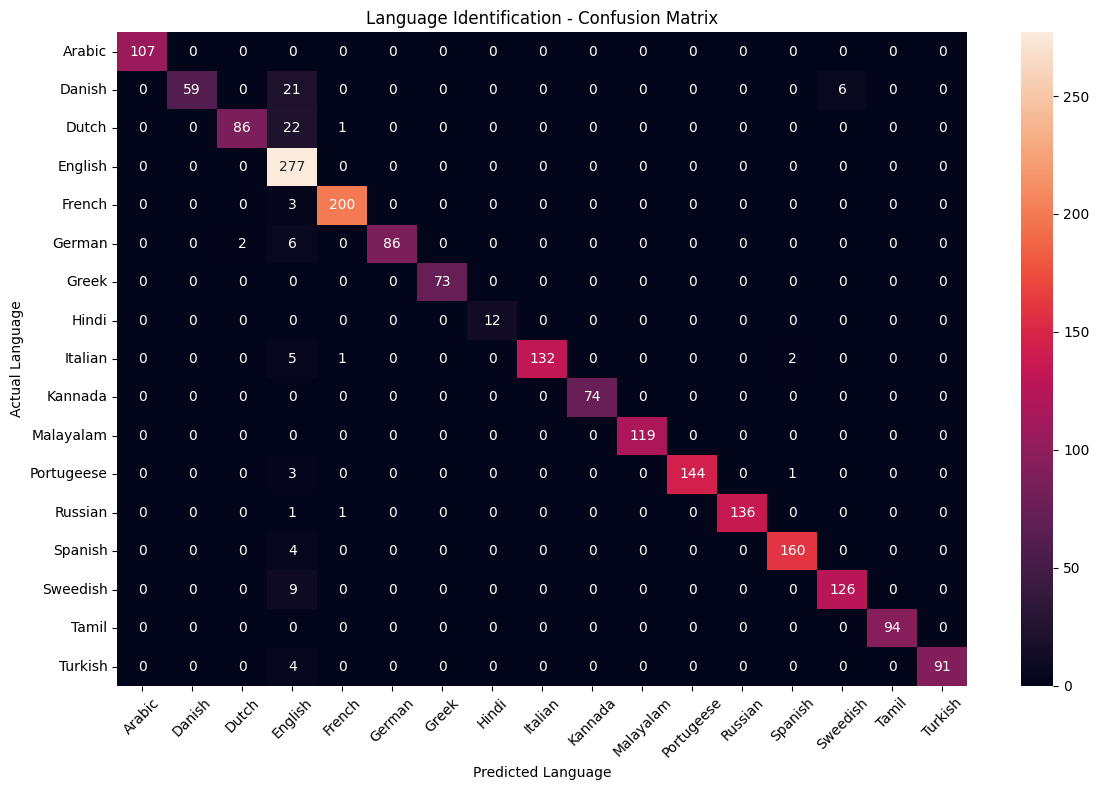

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Language Identification - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Language Identification ---")

while True:

    sentence = input("\nEnter a sentence (or type 'exit'): ")

    if sentence.lower() == "exit":
        break

    sentence_vector = vectorizer.transform([sentence])

    prediction = model.predict(sentence_vector)

    print("Predicted Language:", prediction[0])


--- Language Identification ---

Enter a sentence (or type 'exit'): Hi
Predicted Language: English

Enter a sentence (or type 'exit'): apka naam kyahe
Predicted Language: Dutch

Enter a sentence (or type 'exit'):     வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?
Predicted Language: Tamil

Enter a sentence (or type 'exit'): नमस्ते, आप कैसे हैं
Predicted Language: Hindi

Enter a sentence (or type 'exit'): മലയാളം വളരെ മനോഹരമായ ഭാഷയാണ്
Predicted Language: Malayalam
